<div align="center">
<h1><b> Tariff Pricing Agent </b></h1>
</div>

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Setting up the visualisation parameters
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

In [ ]:
# Load demand Predictions
# Load predictions from Notebook 3

'''The tariff agent's entire logic is driven by the predicted utilization values 
from Notebook 3. It consumes those predictions and converts them into pricing decisions.'''

predictions = pd.read_csv(
    '../outputs/demand_agent/demand_predictions.csv',
    parse_dates=['datetime']
)

# Load urban data for additional context
urban = pd.read_csv(
    '../data/processed/clean_urban_data.csv',
    parse_dates=['datetime']
)

print("Predictions shape:", predictions.shape)
print("Columns:", predictions.columns.tolist())
print("\nSample:")
print(predictions.head())
print("\nPredicted utilization stats:")
print(predictions['predicted_utilization'].describe().round(4))

Predictions shape: (411996, 13)
Columns: ['datetime', 'station_id', 'hour', 'day_of_week', 'period_enc', 'is_weekend', 'period', 'predicted_utilization', 'actual_utilization', 'congestion_flag', 'underutil_flag', 'predicted_load_chargers', 'prediction_error']

Sample:
             datetime  station_id  hour  day_of_week  period_enc  is_weekend  \
0 2022-07-13 04:00:00         698     4            2           0           0   
1 2022-07-13 04:00:00         577     4            2           0           0   
2 2022-07-13 04:00:00         224     4            2           0           0   
3 2022-07-13 04:00:00         986     4            2           0           0   
4 2022-07-13 04:00:00         594     4            2           0           0   

     period  predicted_utilization  actual_utilization  congestion_flag  \
0  off_peak               0.340266            0.333333                0   
1  off_peak               0.206562            0.208333                0   
2  off_peak              

In [3]:
# ============================================================
# TARIFF PRICING AGENT — CALIBRATED TO NETWORK PROFILE
# This network has avg utilization ~0.29 (heavily underutilized)
# So discounts must be conservative — attract volume without
# destroying revenue. Surge must be aggressive where it occurs.
# ============================================================

BASE_TARIFF      = 15.0   # ₹/kWh fixed baseline
SURGE_THRESH     = 0.80   # above → surge
DISCOUNT_THRESH  = 0.30   # below → discount

# Calibrated caps — conservative discount, aggressive surge
SURGE_CAP        = BASE_TARIFF * 1.60   # max ₹24.00/kWh (+60%)
DISCOUNT_FLOOR   = BASE_TARIFF * 0.88   # min ₹13.20/kWh (-12% only)

# Demand elasticity assumptions (documented)
SURGE_ELASTICITY    = -0.15   # surge reduces demand by 15%
DISCOUNT_ELASTICITY = 0.20   # discount increases demand by 20%

def compute_dynamic_tariff(utilization):
    """
    Surge zone    (>80%): Scale up linearly to +60% above base
    Baseline zone (30-80%): Mild ±3% adjustment
    Discount zone (<30%): Conservative scale down max -12%
    
    Discount is kept conservative because:
    - 58.8% of slots are in discount zone
    - Aggressive discounts destroy more revenue than surge recovers
    - Goal: attract volume while preserving revenue floor
    """
    if utilization > SURGE_THRESH:
        surge_factor = (utilization - SURGE_THRESH) / (1.0 - SURGE_THRESH)
        tariff = BASE_TARIFF + surge_factor * (SURGE_CAP - BASE_TARIFF)

    elif utilization < DISCOUNT_THRESH:
        discount_factor = (DISCOUNT_THRESH - utilization) / DISCOUNT_THRESH
        tariff = BASE_TARIFF - discount_factor * (BASE_TARIFF - DISCOUNT_FLOOR)

    else:
        mid_point = (SURGE_THRESH + DISCOUNT_THRESH) / 2
        deviation = (utilization - mid_point) / (SURGE_THRESH - mid_point)
        tariff = BASE_TARIFF * (1 + deviation * 0.03)

    return round(np.clip(tariff, DISCOUNT_FLOOR, SURGE_CAP), 4)

def get_pricing_regime(utilization):
    """
    Tells us which pricing regime has to be followed under which condition
    """
    if utilization > SURGE_THRESH:
        return 'surge'
    elif utilization < DISCOUNT_THRESH:
        return 'discount'
    else:
        return 'baseline'

# Apply tariffs and regimes
predictions['dynamic_tariff'] = predictions['predicted_utilization'].apply(compute_dynamic_tariff)
predictions['pricing_regime'] = predictions['predicted_utilization'].apply(get_pricing_regime)
predictions['fixed_tariff']   = BASE_TARIFF

print("Dynamic tariffs computed")
print("\nPricing Regime Distribution:")
regime_counts = predictions['pricing_regime'].value_counts()
for regime, count in regime_counts.items():
    pct = count / len(predictions) * 100
    print(f"   {regime:<12}: {count:>8,} slots ({pct:.1f}%)")

print(f"\nTariff Range:")
print(f"   Min dynamic tariff: ₹{predictions['dynamic_tariff'].min():.2f}/kWh")
print(f"   Max dynamic tariff: ₹{predictions['dynamic_tariff'].max():.2f}/kWh")
print(f"   Avg dynamic tariff: ₹{predictions['dynamic_tariff'].mean():.2f}/kWh")
print(f"   Fixed baseline:     ₹{BASE_TARIFF:.2f}/kWh")

Dynamic tariffs computed

Pricing Regime Distribution:
   discount    :  244,114 slots (59.3%)
   baseline    :  165,383 slots (40.1%)
   surge       :    2,499 slots (0.6%)

Tariff Range:
   Min dynamic tariff: ₹13.20/kWh
   Max dynamic tariff: ₹24.00/kWh
   Avg dynamic tariff: ₹14.50/kWh
   Fixed baseline:     ₹15.00/kWh


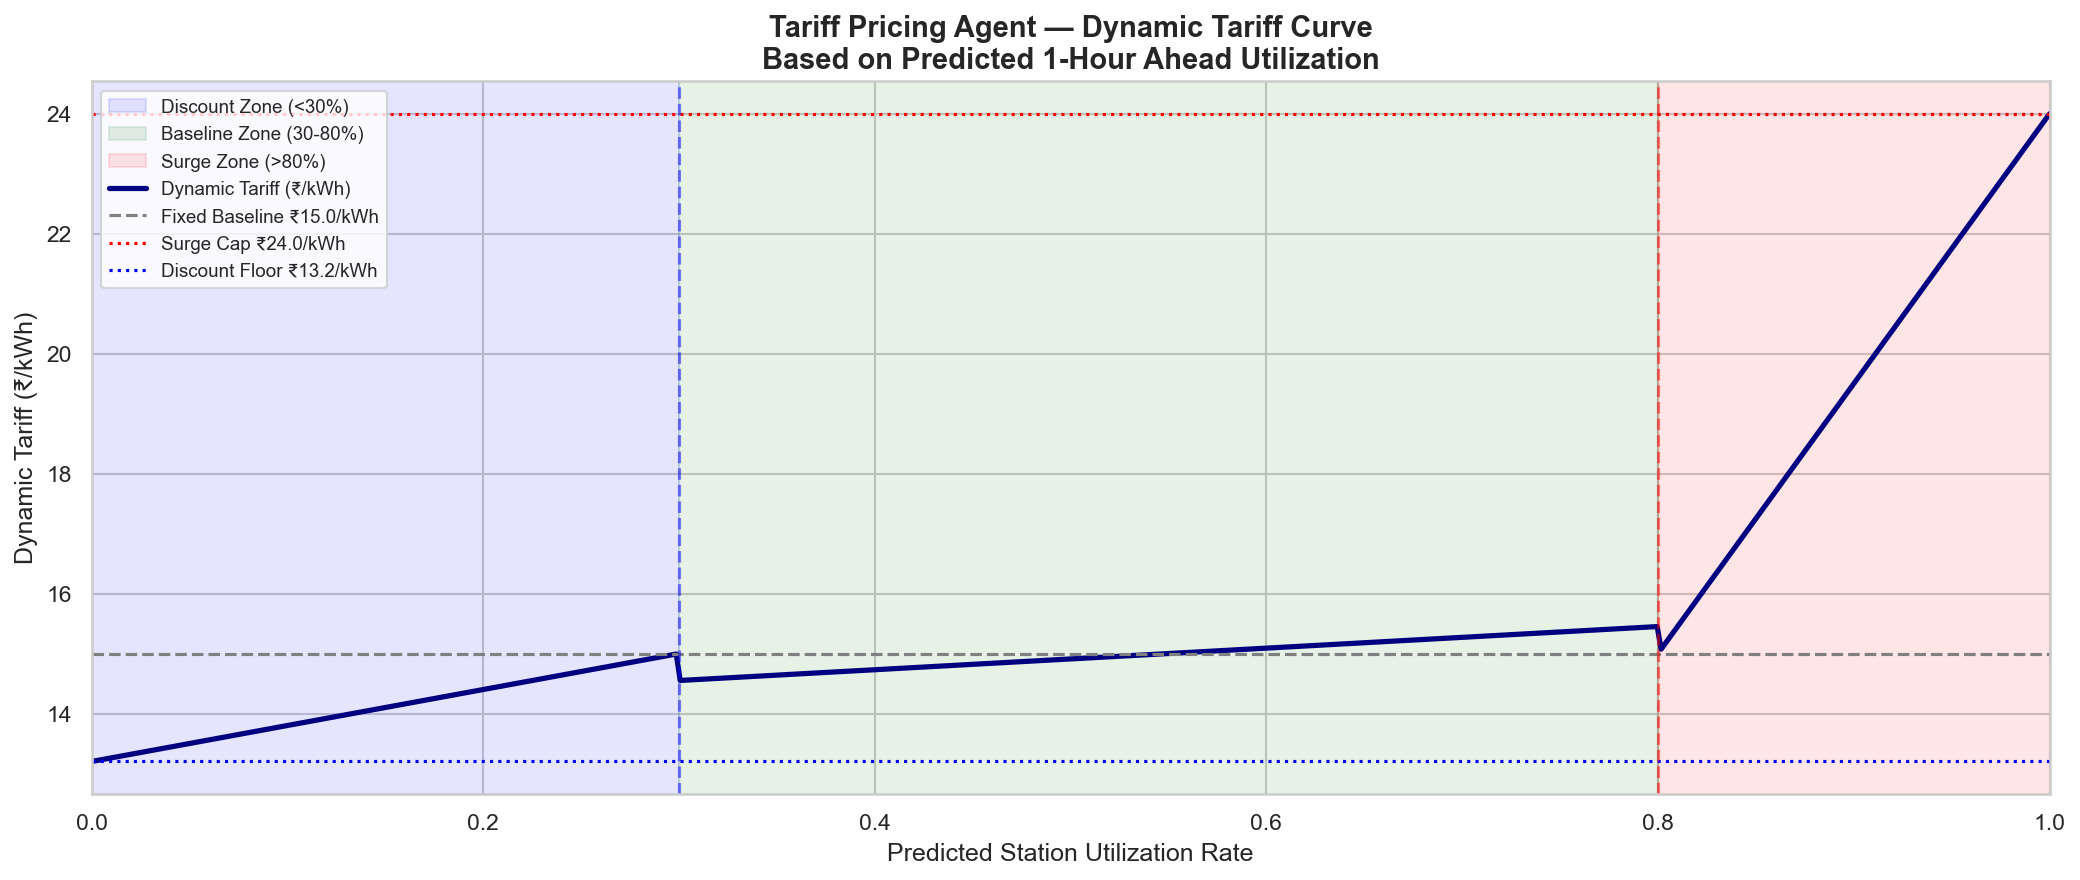

Saved: tariff_curve.png


In [4]:
# Visualisation of Tariff Curve
# Show how tariff changes across utilization range from 0.0 to 1.0.
util_range = np.linspace(0, 1, 500)
tariff_curve = [compute_dynamic_tariff(u) for u in util_range]

fig, ax = plt.subplots(figsize=(14, 6))

# Color zones
ax.axvspan(0,              DISCOUNT_THRESH, alpha=0.10, color='blue',  label='Discount Zone (<30%)')
ax.axvspan(DISCOUNT_THRESH, SURGE_THRESH,   alpha=0.10, color='green', label='Baseline Zone (30-80%)')
ax.axvspan(SURGE_THRESH,   1.0,             alpha=0.10, color='red',   label='Surge Zone (>80%)')

# Tariff curve
ax.plot(util_range, tariff_curve, color='navy', linewidth=2.5, label='Dynamic Tariff (₹/kWh)')
ax.axhline(BASE_TARIFF,    color='gray',  linestyle='--', linewidth=1.5, label=f'Fixed Baseline ₹{BASE_TARIFF}/kWh')
ax.axhline(SURGE_CAP,      color='red',   linestyle=':',  linewidth=1.5, label=f'Surge Cap ₹{SURGE_CAP}/kWh')
ax.axhline(DISCOUNT_FLOOR, color='blue',  linestyle=':',  linewidth=1.5, label=f'Discount Floor ₹{DISCOUNT_FLOOR}/kWh')

# Threshold lines
ax.axvline(SURGE_THRESH,    color='red',  linestyle='--', alpha=0.5)
ax.axvline(DISCOUNT_THRESH, color='blue', linestyle='--', alpha=0.5)

ax.set_xlabel('Predicted Station Utilization Rate', fontsize=12)
ax.set_ylabel('Dynamic Tariff (₹/kWh)', fontsize=12)
ax.set_title('Tariff Pricing Agent — Dynamic Tariff Curve\n'
             'Based on Predicted 1-Hour Ahead Utilization',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('../visuals/tariff_agent/tariff_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tariff_curve.png")

In [5]:
# Revenue Simulation: Dynamic vs Fixed
# ============================================================
# Revenue must reflect BOTH price AND volume change
# Step 1: Compute demand response (how utilization shifts)
# Step 2: Use ADJUSTED utilization for energy calculation
# Step 3: Compute revenue = adjusted_energy × tariff
# ============================================================

AVG_CHARGERS_PER_STATION = urban['total_chargers'].mean()
AVG_KW_PER_CHARGER       = 7.0
SLOT_DURATION_HRS        = 5 / 60

# Step 1 — Demand response to pricing
def simulate_adjusted_utilization(row):
    u = row['predicted_utilization']
    if row['pricing_regime'] == 'surge':
        return np.clip(u * (1 + SURGE_ELASTICITY), 0, 1)
    elif row['pricing_regime'] == 'discount':
        return np.clip(u * (1 + DISCOUNT_ELASTICITY), 0, 1)
    else:
        return u

predictions['adjusted_utilization'] = predictions.apply(
    simulate_adjusted_utilization, axis=1
)

# Step 2 — Energy based on ORIGINAL utilization (fixed pricing scenario)
predictions['energy_fixed_kwh'] = (
    predictions['predicted_utilization'] *
    AVG_CHARGERS_PER_STATION *
    AVG_KW_PER_CHARGER *
    SLOT_DURATION_HRS
).round(4)

# Step 3 — Energy based on ADJUSTED utilization (dynamic pricing scenario)
# Discount attracts more users → more energy delivered
# Surge deters some users → less energy but at higher price
predictions['energy_dynamic_kwh'] = (
    predictions['adjusted_utilization'] *
    AVG_CHARGERS_PER_STATION *
    AVG_KW_PER_CHARGER *
    SLOT_DURATION_HRS
).round(4)

# Step 4 — Revenue calculations
predictions['revenue_fixed']   = (predictions['energy_fixed_kwh']   * BASE_TARIFF).round(4)
predictions['revenue_dynamic'] = (predictions['energy_dynamic_kwh'] * predictions['dynamic_tariff']).round(4)
predictions['revenue_delta']   = (predictions['revenue_dynamic'] - predictions['revenue_fixed']).round(4)

# Totals
total_fixed   = predictions['revenue_fixed'].sum()
total_dynamic = predictions['revenue_dynamic'].sum()
revenue_gain  = ((total_dynamic - total_fixed) / total_fixed) * 100

print("=" * 50)
print(f"  Fixed Revenue (baseline):  ₹{total_fixed:>14,.2f}")
print(f"  Dynamic Revenue:           ₹{total_dynamic:>14,.2f}")
print(f"  Revenue Gain:               {revenue_gain:>13.2f}%")
print("=" * 50)

# Breakdown by regime
print("\nRevenue Breakdown by Pricing Regime:")
for regime in ['surge', 'baseline', 'discount']:
    sub = predictions[predictions['pricing_regime'] == regime]
    r_dyn = sub['revenue_dynamic'].sum()
    r_fix = sub['revenue_fixed'].sum()
    gain  = ((r_dyn - r_fix) / r_fix * 100) if r_fix > 0 else 0
    print(f"   {regime:<12}: Dynamic ₹{r_dyn:>12,.2f} | "
          f"Fixed ₹{r_fix:>12,.2f} | Gain: {gain:>+6.2f}%")

  Fixed Revenue (baseline):  ₹ 75,991,806.12
  Dynamic Revenue:           ₹ 79,918,387.21
  Revenue Gain:                        5.17%

Revenue Breakdown by Pricing Regime:
   surge       : Dynamic ₹1,453,656.88 | Fixed ₹1,394,699.50 | Gain:  +4.23%
   baseline    : Dynamic ₹46,597,752.57 | Fixed ₹47,023,209.25 | Gain:  -0.90%
   discount    : Dynamic ₹31,866,977.76 | Fixed ₹27,573,897.37 | Gain: +15.57%


Regime Revenue:
                total_dynamic_rev  total_fixed_rev  avg_tariff  slot_count  revenue_gain_pct
pricing_regime                                                                              
baseline              46597752.57      47023209.25       14.81      165383             -0.90
discount              31866977.76      27573897.37       14.26      244114             15.57
surge                  1453656.88       1394699.50       18.25        2499              4.23


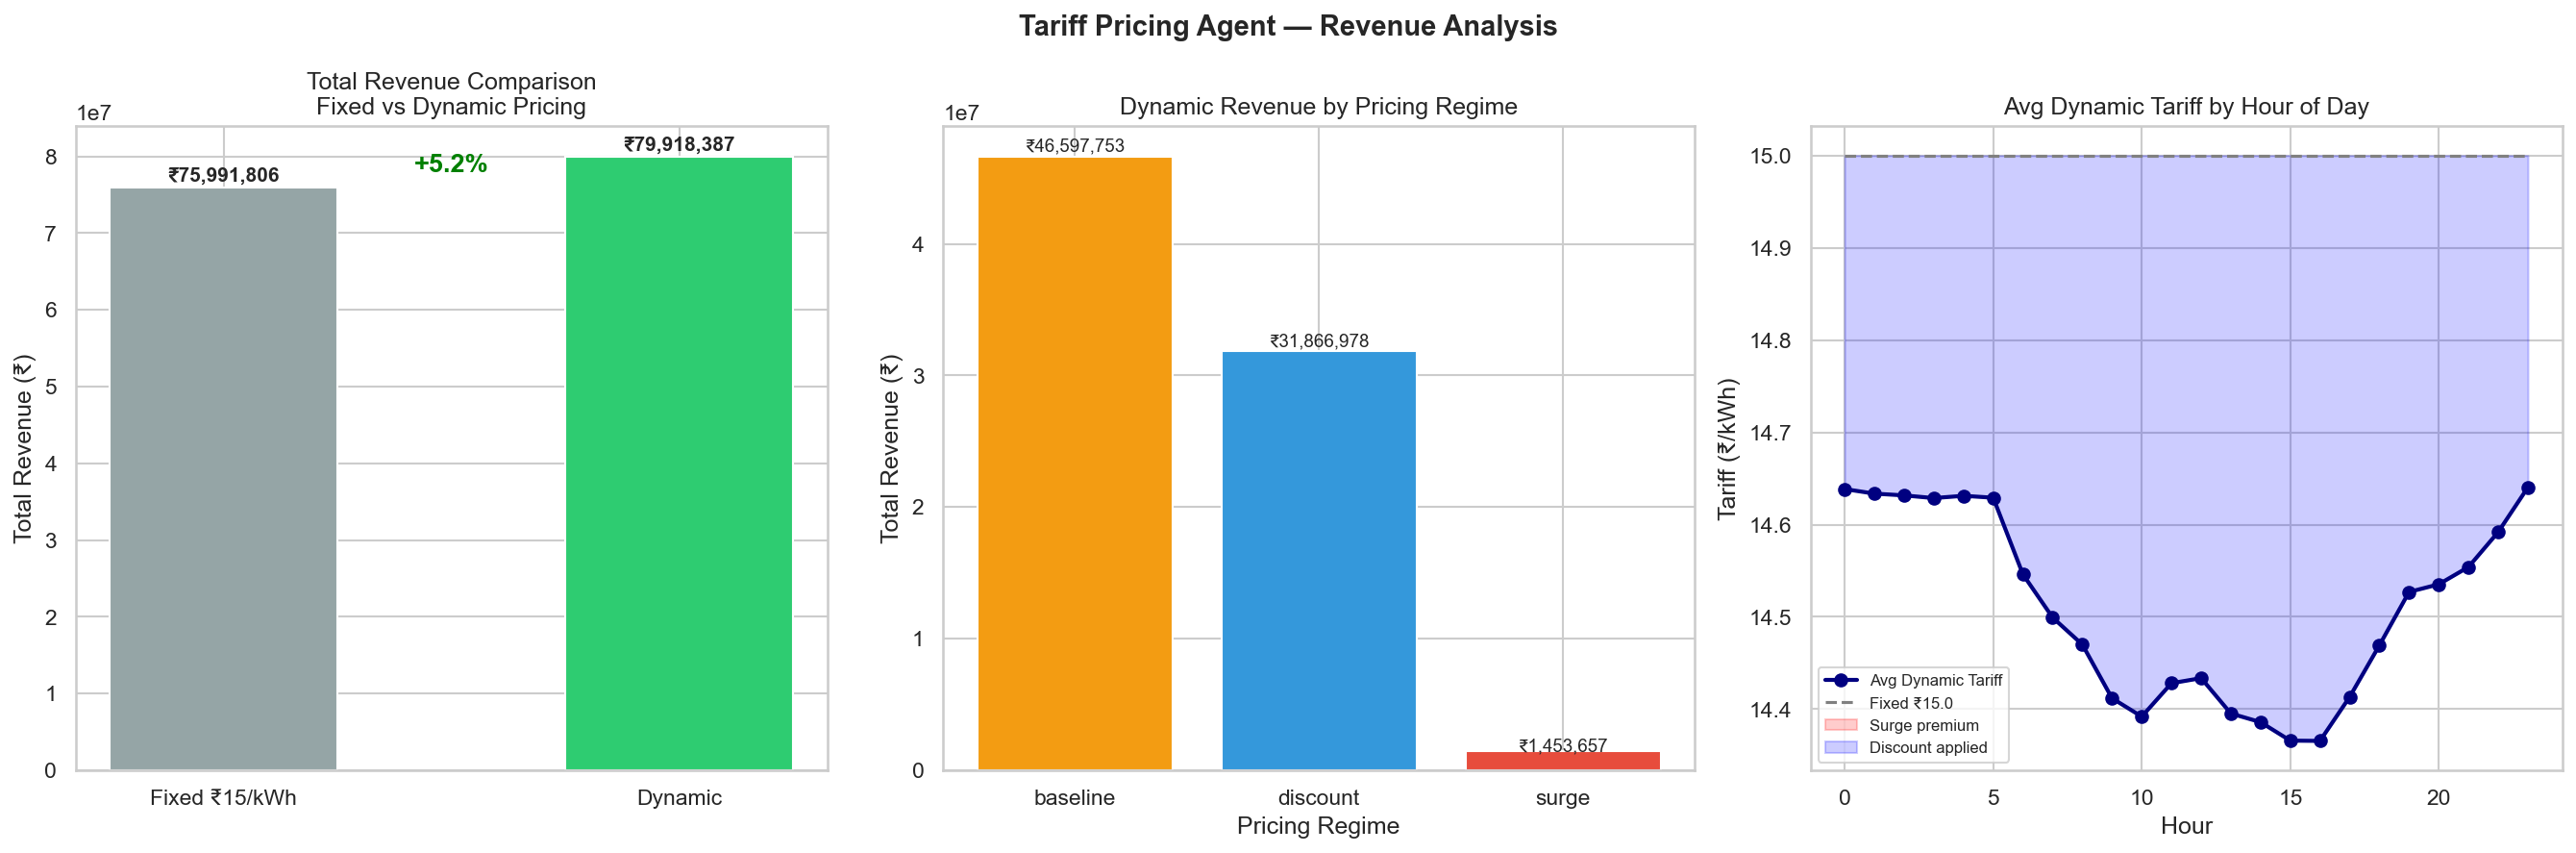

Saved: revenue_comparison.png


In [ ]:
# Comparsion of Revenue Visualisation
# Compute regime_revenue for visualization
# ============================================================
regime_revenue = predictions.groupby('pricing_regime').agg(
    total_dynamic_rev=('revenue_dynamic', 'sum'),
    total_fixed_rev=('revenue_fixed', 'sum'),
    avg_tariff=('dynamic_tariff', 'mean'),
    slot_count=('revenue_dynamic', 'count')
).round(2)

regime_revenue['revenue_gain_pct'] = (
    (regime_revenue['total_dynamic_rev'] - regime_revenue['total_fixed_rev']) /
     regime_revenue['total_fixed_rev'] * 100
).round(2)

print("Regime Revenue:")
print(regime_revenue.to_string())

# ============================================================
# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Total revenue comparison bar chart
# Comparison of revenue generated from fixed vs dynamic pricing
rev_compare = pd.DataFrame({
    'Pricing':  ['Fixed ₹15/kWh', 'Dynamic'],
    'Revenue':  [total_fixed, total_dynamic],
    'Color':    ['#95a5a6', '#2ecc71']
})
bars = axes[0].bar(
    rev_compare['Pricing'],
    rev_compare['Revenue'],
    color=rev_compare['Color'],
    edgecolor='white', width=0.5
)
axes[0].set_title('Total Revenue Comparison\nFixed vs Dynamic Pricing')
axes[0].set_ylabel('Total Revenue (₹)')
for bar, val in zip(bars, rev_compare['Revenue']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() * 1.01,
                 f'₹{val:,.0f}', ha='center', fontsize=10, fontweight='bold')
axes[0].annotate(f'+{revenue_gain:.1f}%',
                  xy=(1, total_dynamic), xytext=(0.5, (total_fixed + total_dynamic)/2),
                  fontsize=13, color='green', fontweight='bold', ha='center')

# 2. Revenue by pricing regime
# Which Pricing Regime contributed how much
regime_colors = {'surge':'#e74c3c','baseline':'#f39c12','discount':'#3498db'}
regime_rev_plot = regime_revenue.reset_index()
bars2 = axes[1].bar(
    regime_rev_plot['pricing_regime'],
    regime_rev_plot['total_dynamic_rev'],
    color=[regime_colors[r] for r in regime_rev_plot['pricing_regime']],
    edgecolor='white'
)
axes[1].set_title('Dynamic Revenue by Pricing Regime')
axes[1].set_ylabel('Total Revenue (₹)')
axes[1].set_xlabel('Pricing Regime')
for bar, val in zip(bars2, regime_rev_plot['total_dynamic_rev']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() * 1.01,
                 f'₹{val:,.0f}', ha='center', fontsize=9)

# 3. Avg tariff by hour
# When during the day does pricing deviate from baseline and by how much
tariff_hourly = predictions.groupby('hour')['dynamic_tariff'].mean()
fixed_line    = [BASE_TARIFF] * 24

axes[2].plot(tariff_hourly.index, tariff_hourly.values,
             marker='o', color='navy', linewidth=2, label='Avg Dynamic Tariff')
axes[2].plot(range(24), fixed_line,
             linestyle='--', color='gray', linewidth=1.5, label=f'Fixed ₹{BASE_TARIFF}')
axes[2].fill_between(tariff_hourly.index, BASE_TARIFF, tariff_hourly.values,
                      where=tariff_hourly.values > BASE_TARIFF,
                      alpha=0.2, color='red', label='Surge premium')
axes[2].fill_between(tariff_hourly.index, BASE_TARIFF, tariff_hourly.values,
                      where=tariff_hourly.values < BASE_TARIFF,
                      alpha=0.2, color='blue', label='Discount applied')
axes[2].set_title('Avg Dynamic Tariff by Hour of Day')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('Tariff (₹/kWh)')
axes[2].legend(fontsize=8)

plt.suptitle('Tariff Pricing Agent — Revenue Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/tariff_agent/revenue_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: revenue_comparison.png")

In [8]:
# Charger Utilisation Before vs After Pricing
# Simulate demand response to pricing

# Economic assumption (documented):
# Surge pricing → some users defer → utilization drops ~10-15%
# Discount pricing → attracts new sessions → utilization rises ~10-20%
# Baseline → negligible change

def simulate_adjusted_utilization(row):
    u = row['predicted_utilization']
    if row['pricing_regime'] == 'surge':
        # Higher price deters some demand
        elasticity = -0.15
        return np.clip(u * (1 + elasticity), 0, 1)
    elif row['pricing_regime'] == 'discount':
        # Lower price attracts demand
        elasticity = +0.18
        return np.clip(u * (1 + elasticity), 0, 1)
    else:
        return u

predictions['adjusted_utilization'] = predictions.apply(
    simulate_adjusted_utilization, axis=1
)

# Before dynamic pricing vs after dynamic pricing stats
before_avg = predictions['predicted_utilization'].mean()
after_avg  = predictions['adjusted_utilization'].mean()
before_cong = (predictions['predicted_utilization'] > 0.8).mean() * 100
after_cong  = (predictions['adjusted_utilization'] > 0.8).mean() * 100
before_under = (predictions['predicted_utilization'] < 0.3).mean() * 100
after_under  = (predictions['adjusted_utilization'] < 0.3).mean() * 100

print("=== Utilization Impact of Dynamic Pricing ===")
print(f"{'Metric':<30} {'Before':>10} {'After':>10} {'Change':>10}")
print("-" * 62)
print(f"{'Avg Utilization':<30} {before_avg:>10.4f} {after_avg:>10.4f} {after_avg-before_avg:>+10.4f}")
print(f"{'Congested Slots % (>80%)':<30} {before_cong:>10.2f} {after_cong:>10.2f} {after_cong-before_cong:>+10.2f}")
print(f"{'Underutilized Slots % (<30%)':<30} {before_under:>10.2f} {after_under:>10.2f} {after_under-before_under:>+10.2f}")

=== Utilization Impact of Dynamic Pricing ===
Metric                             Before      After     Change
--------------------------------------------------------------
Avg Utilization                    0.2883     0.3063    +0.0180
Congested Slots % (>80%)             0.61       0.08      -0.53
Underutilized Slots % (<30%)        59.25      48.65     -10.60


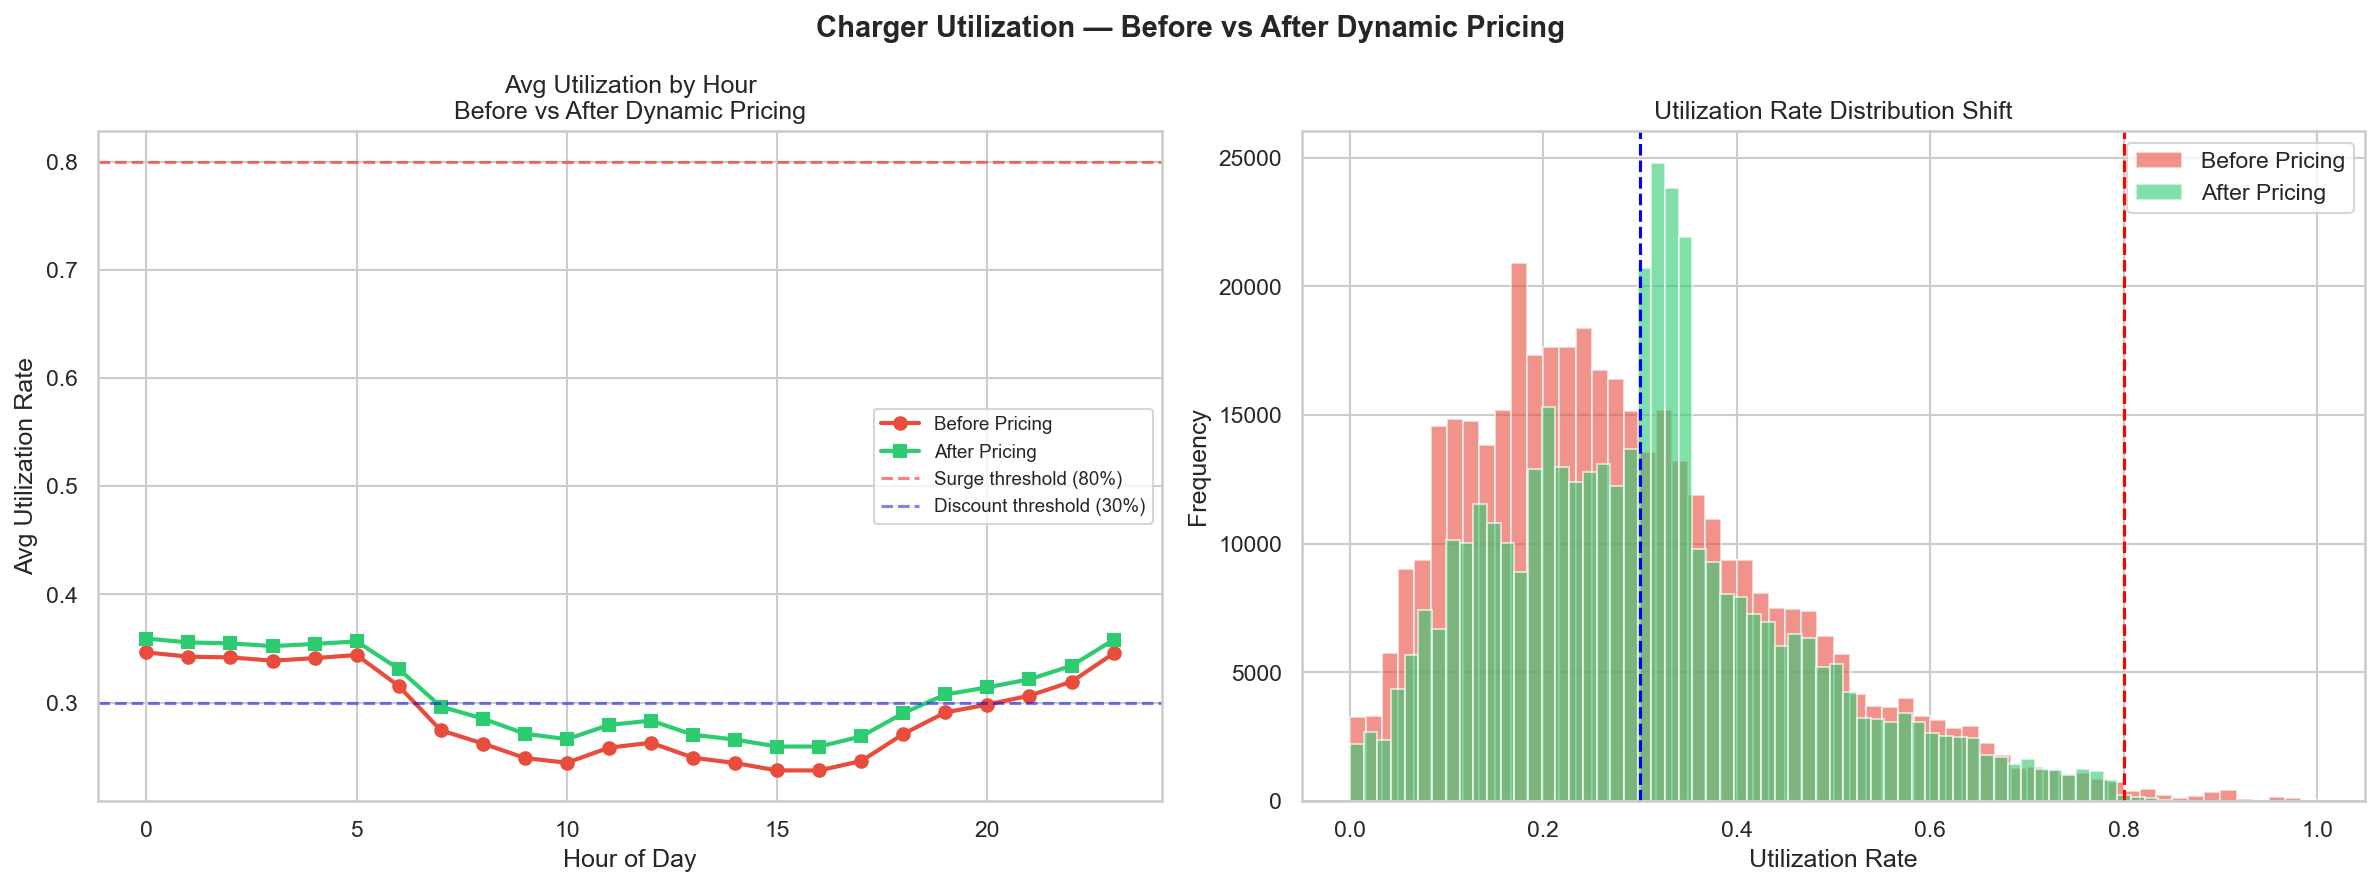

Saved: utilization_before_after.png


In [9]:
# Visualisation of Charger Utilisation before vs after  dynamic pricing
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Hourly utilization before vs after dynamic pricing 

before_hourly = predictions.groupby('hour')['predicted_utilization'].mean()
after_hourly  = predictions.groupby('hour')['adjusted_utilization'].mean()

axes[0].plot(before_hourly.index, before_hourly.values,
             marker='o', color='#e74c3c', linewidth=2, label='Before Pricing')
axes[0].plot(after_hourly.index, after_hourly.values,
             marker='s', color='#2ecc71', linewidth=2, label='After Pricing')
axes[0].axhline(SURGE_THRESH,    color='red',  linestyle='--', alpha=0.5, label='Surge threshold (80%)')
axes[0].axhline(DISCOUNT_THRESH, color='blue', linestyle='--', alpha=0.5, label='Discount threshold (30%)')
axes[0].set_title('Avg Utilization by Hour\nBefore vs After Dynamic Pricing')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Utilization Rate')
axes[0].legend(fontsize=9)

# Distribution shift of utilization rates before vs after dynamic pricing

axes[1].hist(predictions['predicted_utilization'], bins=60,
             alpha=0.6, color='#e74c3c', label='Before Pricing', edgecolor='white')
axes[1].hist(predictions['adjusted_utilization'], bins=60,
             alpha=0.6, color='#2ecc71', label='After Pricing', edgecolor='white')
axes[1].axvline(SURGE_THRESH,    color='red',  linestyle='--', linewidth=1.5)
axes[1].axvline(DISCOUNT_THRESH, color='blue', linestyle='--', linewidth=1.5)
axes[1].set_title('Utilization Rate Distribution Shift')
axes[1].set_xlabel('Utilization Rate')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Charger Utilization — Before vs After Dynamic Pricing',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/tariff_agent/utilization_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: utilization_before_after.png")

=== Off-Peak Uplift Analysis ===
Total discount slots:       244,114
Slots with uplift:          243,944 (99.9%)
Avg utilization uplift:     0.0318 (3.18%)
Avg tariff in discount zone: ₹14.26/kWh
  vs fixed baseline:         ₹15.00/kWh


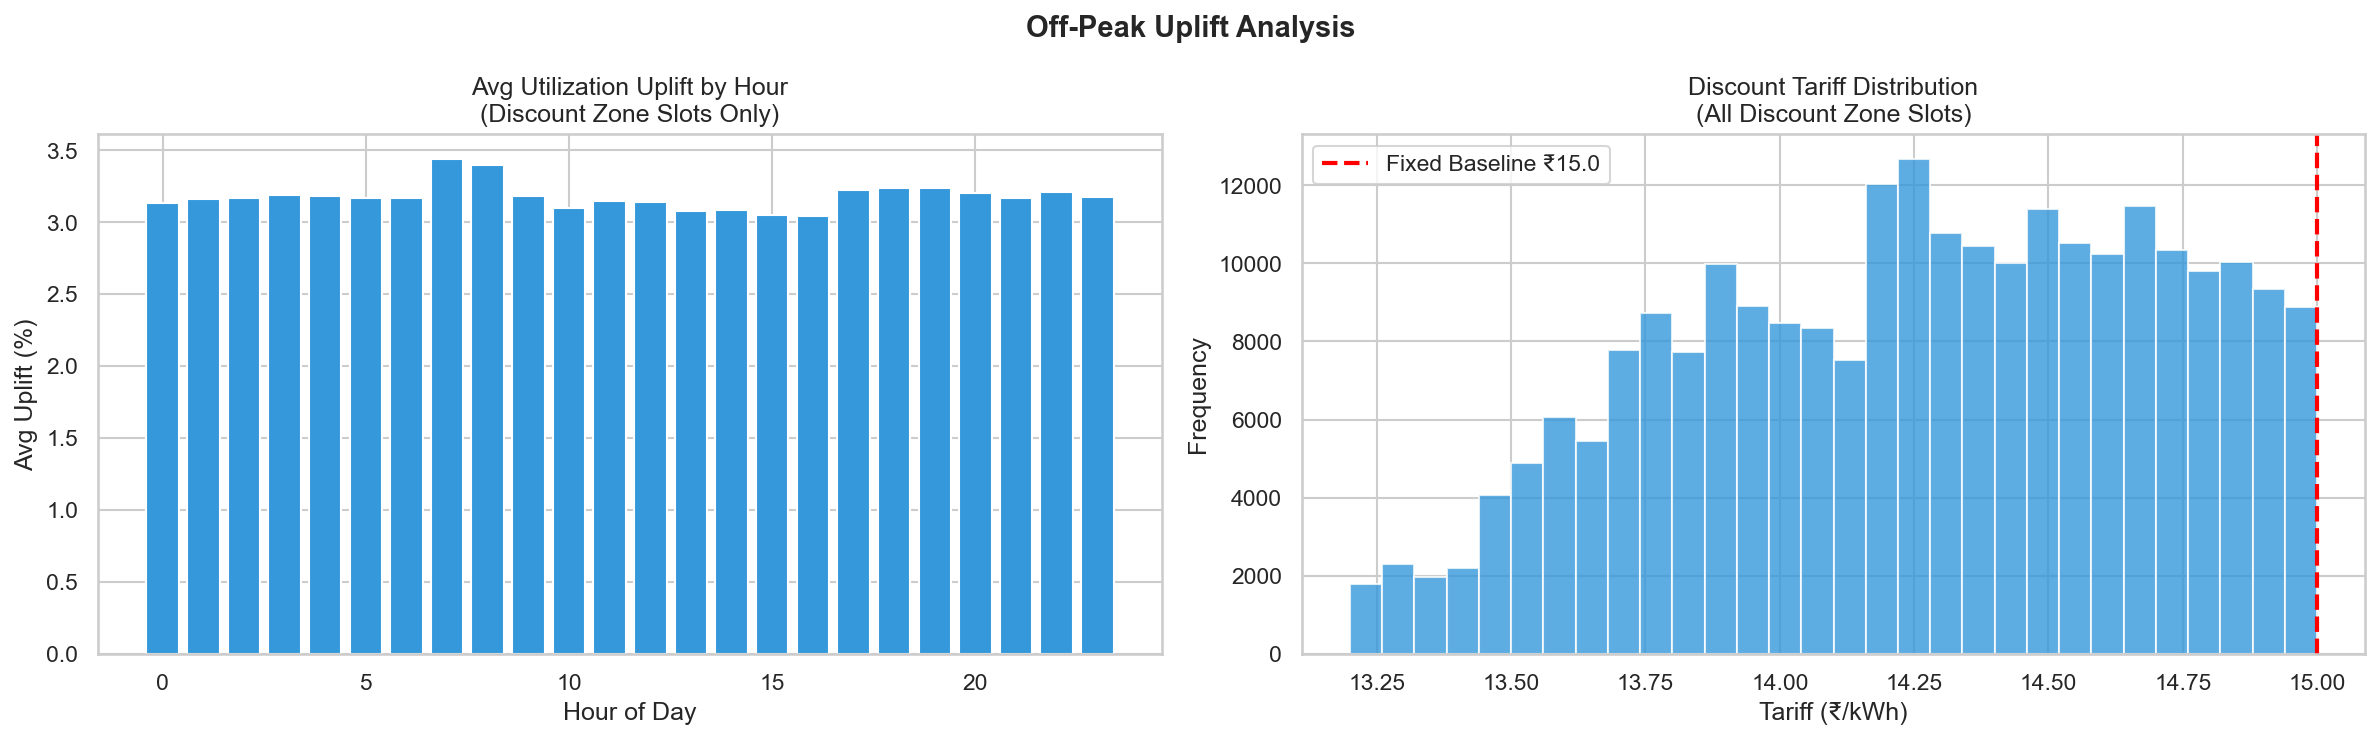

Saved: offpeak_uplift.png


In [10]:
# Off Peak Uplift Analysis
# Sessions that were underutilized BEFORE pricing
# and gained utilization AFTER discount was applied

offpeak = predictions[predictions['pricing_regime'] == 'discount'].copy()
offpeak['utilization_uplift'] = (
    offpeak['adjusted_utilization'] - offpeak['predicted_utilization']
)

# Revenue uplift in off-peak (more sessions = more revenue even at discount)
offpeak['revenue_after_discount'] = (
    offpeak['energy_dynamic_kwh'] * offpeak['dynamic_tariff']
)

avg_uplift      = offpeak['utilization_uplift'].mean()
total_slots     = len(offpeak)
uplifted_slots  = (offpeak['utilization_uplift'] > 0).sum()

print("=== Off-Peak Uplift Analysis ===")
print(f"Total discount slots:       {total_slots:,}")
print(f"Slots with uplift:          {uplifted_slots:,} ({uplifted_slots/total_slots*100:.1f}%)")
print(f"Avg utilization uplift:     {avg_uplift:.4f} ({avg_uplift*100:.2f}%)")
print(f"Avg tariff in discount zone: ₹{offpeak['dynamic_tariff'].mean():.2f}/kWh")
print(f"  vs fixed baseline:         ₹{BASE_TARIFF:.2f}/kWh")

# Visualize off peak uplift by hour
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

uplift_by_hour = offpeak.groupby('hour')['utilization_uplift'].mean()
axes[0].bar(uplift_by_hour.index, uplift_by_hour.values * 100,
            color='#3498db', edgecolor='white')
axes[0].set_title('Avg Utilization Uplift by Hour\n(Discount Zone Slots Only)')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Uplift (%)')

# Tariff distribution in discount zone
axes[1].hist(offpeak['dynamic_tariff'], bins=30,
             color='#3498db', edgecolor='white', alpha=0.8)
axes[1].axvline(BASE_TARIFF, color='red', linestyle='--',
                linewidth=2, label=f'Fixed Baseline ₹{BASE_TARIFF}')
axes[1].set_title('Discount Tariff Distribution\n(All Discount Zone Slots)')
axes[1].set_xlabel('Tariff (₹/kWh)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Off-Peak Uplift Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/tariff_agent/offpeak_uplift.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: offpeak_uplift.png")

In [11]:
# Pricing Efficiency Score
# Pricing Efficiency = Revenue per kWh delivered
# Higher = better use of energy capacity

efficiency_fixed   = total_fixed / predictions['energy_dynamic_kwh'].sum()
efficiency_dynamic = total_dynamic / predictions['energy_dynamic_kwh'].sum()

print("=== Pricing Efficiency Score ===")
print(f"Fixed pricing:   ₹{efficiency_fixed:.4f} per kWh")
print(f"Dynamic pricing: ₹{efficiency_dynamic:.4f} per kWh")
print(f"Efficiency gain: {((efficiency_dynamic-efficiency_fixed)/efficiency_fixed)*100:.2f}%")

# Efficiency by pricing regime
eff_by_regime = predictions.groupby('pricing_regime').apply(
    lambda x: x['revenue_dynamic'].sum() / x['energy_dynamic_kwh'].sum()
).reset_index()
eff_by_regime.columns = ['pricing_regime','revenue_per_kwh']

print("\nEfficiency by Regime:")
print(eff_by_regime.to_string(index=False))

=== Pricing Efficiency Score ===
Fixed pricing:   ₹14.0211 per kWh
Dynamic pricing: ₹14.7456 per kWh
Efficiency gain: 5.17%

Efficiency by Regime:
pricing_regime  revenue_per_kwh
      baseline        14.864283
      discount        14.446170
         surge        18.393043


In [12]:
# Exporting Tariff Agent CSVs
# 1. Full tariff recommendations
tariff_out = predictions[[
    'datetime', 'station_id', 'hour', 'day_of_week', 'is_weekend',
    'predicted_utilization', 'dynamic_tariff', 'fixed_tariff',
    'pricing_regime', 'energy_dynamic_kwh',
    'revenue_dynamic', 'revenue_fixed', 'revenue_delta',
    'adjusted_utilization'
]].copy()
tariff_out.to_csv('../outputs/tariff_agent/tariff_recommendations.csv', index=False)
print("Saved: tariff_recommendations.csv →", tariff_out.shape)

# 2. Revenue comparison summary
revenue_summary = pd.DataFrame({
    'metric': [
        'Fixed Revenue (₹)',
        'Dynamic Revenue (₹)',
        'Revenue Gain (%)',
        'Fixed Pricing Efficiency (₹/kWh)',
        'Dynamic Pricing Efficiency (₹/kWh)'
    ],
    'value': [
        round(total_fixed, 2),
        round(total_dynamic, 2),
        round(revenue_gain, 4),
        round(efficiency_fixed, 4),
        round(efficiency_dynamic, 4)
    ]
})
revenue_summary.to_csv('../outputs/tariff_agent/revenue_comparison.csv', index=False)
print("Saved: revenue_comparison.csv")

# 3. Utilization before vs after
util_compare = predictions[[
    'datetime', 'station_id', 'hour', 'pricing_regime',
    'predicted_utilization', 'adjusted_utilization'
]].copy()
util_compare.columns = [
    'datetime', 'station_id', 'hour', 'regime',
    'utilization_before', 'utilization_after'
]
util_compare['utilization_change'] = (
    util_compare['utilization_after'] - util_compare['utilization_before']
).round(5)
util_compare.to_csv('../outputs/tariff_agent/utilization_before_after.csv', index=False)
print("Saved: utilization_before_after.csv →", util_compare.shape)

# 4. Off-peak uplift
offpeak_out = offpeak[[
    'datetime', 'station_id', 'hour',
    'predicted_utilization', 'adjusted_utilization',
    'utilization_uplift', 'dynamic_tariff'
]].copy()
offpeak_out.to_csv('../outputs/tariff_agent/offpeak_uplift.csv', index=False)
print("Saved: offpeak_uplift.csv →", offpeak_out.shape)

# 5. Tariff pricing rules config
import json
rules = {
    'base_tariff_inr':    BASE_TARIFF,
    'surge_threshold':    SURGE_THRESH,
    'discount_threshold': DISCOUNT_THRESH,
    'surge_cap_inr':      SURGE_CAP,
    'discount_floor_inr': DISCOUNT_FLOOR,
    'surge_elasticity':   -0.15,
    'discount_elasticity': 0.18,
    'forecast_horizon_slots': 12,
    'forecast_horizon_hrs':   1
}
with open('../models/tariff_agent/tariff_pricing_rules.json', 'w') as f:
    json.dump(rules, f, indent=4)
print("Saved: tariff_pricing_rules.json")

print("\nNotebook 4 Complete!")
print(f"\n   Revenue Gain:        {revenue_gain:.2f}%")
print(f"   Fixed Revenue:       ₹{total_fixed:,.2f}")
print(f"   Dynamic Revenue:     ₹{total_dynamic:,.2f}")
print(f"   Congestion reduced:  {before_cong:.1f}% → {after_cong:.1f}%")
print(f"   Avg tariff (dynamic): ₹{predictions['dynamic_tariff'].mean():.2f}/kWh")

Saved: tariff_recommendations.csv → (411996, 14)
Saved: revenue_comparison.csv
Saved: utilization_before_after.csv → (411996, 7)
Saved: offpeak_uplift.csv → (244114, 7)
Saved: tariff_pricing_rules.json

Notebook 4 Complete!

   Revenue Gain:        5.17%
   Fixed Revenue:       ₹75,991,806.12
   Dynamic Revenue:     ₹79,918,387.21
   Congestion reduced:  0.6% → 0.1%
   Avg tariff (dynamic): ₹14.50/kWh
